In [30]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18
from matplotlib.lines import Line2D

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs, get_stellar_mass_mia
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches
from catalog_paper_plots import make_bar_pie

from spectra_focus_plots import add_floating_emission_lines, EMISSION_LINES

import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'tight',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})

MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar
    

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
sample_colors = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }


In [5]:
from consolidate_photometry import load_clean_dwarf_catalog

tot_cat = load_clean_dwarf_catalog()

load_clean_dwarf_catalog
  File: /pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits
  HDU:  MAIN
  Galaxies before filter (DWARF_MASKBIT == 0): 469703
  Galaxies after  filter (DWARF_MASKBIT == 0): 439416 (30287 dropped)


In [17]:
tot_cat = tot_cat[tot_cat["DWARF_PRIMARY"] == True]

In [18]:
len(tot_cat)

436191

In [19]:
np.median(tot_cat["Z"])

np.float64(0.0817150518297256)

In [20]:
np.sum(tot_cat["Z"] > 0.2)/ len(tot_cat["Z"])

np.float64(0.13163270218780304)

In [21]:
print("< 6 Counts =", np.sum((tot_cat["LOG_MSTAR_M24"] < 6)))
print("6 < Mstar < 7 Counts =", np.sum((tot_cat["LOG_MSTAR_M24"] < 7) & (tot_cat["LOG_MSTAR_M24"] > 6)))
print("7 < Mstar < 8 Counts =", np.sum((tot_cat["LOG_MSTAR_M24"] < 8) & (tot_cat["LOG_MSTAR_M24"] > 7)))
print("8 < Mstar < 9 Counts =", np.sum((tot_cat["LOG_MSTAR_M24"] < 9) & (tot_cat["LOG_MSTAR_M24"] > 8)))
print("9 < Mstar < 9.25 Counts =", np.sum((tot_cat["LOG_MSTAR_M24"] < 9.25) & (tot_cat["LOG_MSTAR_M24"] > 9)))
 

< 6 Counts = 43
6 < Mstar < 7 Counts = 1305
7 < Mstar < 8 Counts = 54188
8 < Mstar < 9 Counts = 272020
9 < Mstar < 9.25 Counts = 108634


In [22]:
len(tot_cat)

436191

In [23]:
noelg_mask = (tot_cat["IS_BGS_BRIGHT"] == True) | (tot_cat["IS_BGS_FAINT"] == True)  | (tot_cat["IS_LOWZ"] == True)  

print("< 6 Counts =", np.sum((tot_cat[noelg_mask]["LOG_MSTAR_M24"] < 6)))
print("6 < Mstar < 7 Counts =", np.sum((tot_cat[noelg_mask]["LOG_MSTAR_M24"] < 7) & (tot_cat[noelg_mask]["LOG_MSTAR_M24"] > 6)))
print("7 < Mstar < 8 Counts =", np.sum((tot_cat[noelg_mask]["LOG_MSTAR_M24"] < 8) & (tot_cat[noelg_mask]["LOG_MSTAR_M24"] > 7)))
print("8 < Mstar < 9 Counts =", np.sum((tot_cat[noelg_mask]["LOG_MSTAR_M24"] < 9) & (tot_cat[noelg_mask]["LOG_MSTAR_M24"] > 8)))
print("9 < Mstar < 9.25 Counts =", np.sum((tot_cat[noelg_mask]["LOG_MSTAR_M24"] < 9.25) & (tot_cat[noelg_mask]["LOG_MSTAR_M24"] > 9)))



< 6 Counts = 12
6 < Mstar < 7 Counts = 350
7 < Mstar < 8 Counts = 9217
8 < Mstar < 9 Counts = 169099
9 < Mstar < 9.25 Counts = 104881


In [27]:
len(tot_cat[noelg_mask])

283559

In [33]:
elves_cat[:2]

name,host,survey,m_g,g_r,converted_from_gi,dist_mpc,dist_sbf_mpc
str14,str8,str19,float64,float64,str5,float64,float64
NGC247,NGC253,ELVES (Carlsten+22),9.44,0.47999999999999865,False,3.56,--
dw0047m2623,NGC253,ELVES (Carlsten+22),18.89,0.5600000000000023,False,3.56,--


In [28]:
elves_cat = Table.read("/global/homes/v/virajvm/DESI2_LOWZ/desi_dwarfs/data/elves/confirmed_elves_dwarfs.csv")

In [35]:
elves_cat["mstar_mia"] = get_stellar_mass_mia( elves_cat["g_r"], elves_cat["m_g"], np.zeros_like(elves_cat["m_g"]), d_in_mpc = elves_cat["dist_mpc"], input_zred=False )

In [43]:
elves_dwarfs = elves_cat[(elves_cat["mstar_mia"] < 9.25)]

In [46]:
print("< 6 Counts =", np.sum((elves_dwarfs["mstar_mia"] < 6)))
print("6 < Mstar < 7 Counts =", np.sum((elves_dwarfs["mstar_mia"] < 7) & (elves_dwarfs["mstar_mia"] > 6)))
print("7 < Mstar < 8 Counts =", np.sum((elves_dwarfs["mstar_mia"] < 8) & (elves_dwarfs["mstar_mia"] > 7)))
print("8 < Mstar < 9 Counts =", np.sum((elves_dwarfs["mstar_mia"] < 9) & (elves_dwarfs["mstar_mia"] > 8)))
print("9 < Mstar < 9.25 Counts =", np.sum((elves_dwarfs["mstar_mia"] < 9.25) & (elves_dwarfs["mstar_mia"] > 9)))
 

< 6 Counts = 16
6 < Mstar < 7 Counts = 107
7 < Mstar < 8 Counts = 93
8 < Mstar < 9 Counts = 24
9 < Mstar < 9.25 Counts = 3


In [47]:
16+107+93+24+3

243

/tmp/ipykernel_460224/2253477241.py:90: RuntimeWarning: divide by zero encountered in log10
  mu_r = tot_cat["MAG_R"].data + 2.5*np.log10( 2*np.pi * (tot_cat["R50_R"].data**2) )


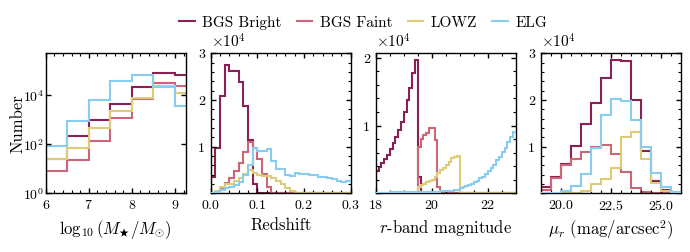

In [17]:


fig,ax = make_subplots(nrow=1,ncol=4,return_fig=True,plot_size=1.4,
                       row_spacing= [MARGIN_LABEL, MARGIN_PAD] ,
                       col_spacing= [MARGIN_LABEL, MARGIN_SHARED+0.15, MARGIN_SHARED+0.15, MARGIN_SHARED+0.15, MARGIN_PAD]
                      )

#first column will be stellar mass, and then redshift and stellar mass
    
text_titles = ["BGS Bright", "BGS Faint", "LOWZ", "ELG"]

samples = ["BGS_BRIGHT","BGS_FAINT","LOWZ","ELG"]

hist_lw = 1.5

mask_i = (tot_cat["SAMPLE"] == "BGS_BRIGHT")
ax[0].hist( tot_cat["LOG_MSTAR_M24"][mask_i], bins = np.arange(6,10,0.5), 
           color = sample_colors[samples[0]], histtype = "step", lw = hist_lw, zorder = 1,alpha = 1, label = "BGS Bright" )

mask_i = (tot_cat["SAMPLE"] == "BGS_FAINT" )
ax[0].hist( tot_cat["LOG_MSTAR_M24"][mask_i], bins = np.arange(6,10,0.5), 
           color = sample_colors[samples[1]], histtype = "step", lw = hist_lw, zorder = 1,label = "BGS Faint" )

mask_i = (tot_cat["SAMPLE"] == "LOWZ" )
ax[0].hist( tot_cat["LOG_MSTAR_M24"][mask_i], bins = np.arange(6,10,0.5), 
           color = sample_colors[samples[2]], histtype = "step", lw = hist_lw, zorder = 1,label = "LOWZ" )

mask_i = (tot_cat["SAMPLE"] == "ELG" )
ax[0].hist( tot_cat["LOG_MSTAR_M24"][mask_i], bins = np.arange(6,10,0.5), 
           color = sample_colors[samples[3]], histtype = "step", lw = hist_lw, zorder = 1,label = "ELG" )


ax[0].set_yscale("log")
ax[0].set_xlim([6,9.25])
ax[0].set_xticks([6,7,8,9])
ax[0].set_ylim([1,5e5])

binw = 0.01

text_titles = ["BGS Bright", "BGS Faint", "LOWZ", "ELG"]

mask_i = (tot_cat["SAMPLE"] == "BGS_BRIGHT")
ax[1].hist(tot_cat["Z"][mask_i], bins = np.arange(0,0.45,binw),
           color = sample_colors[samples[0]], histtype = "step", lw = hist_lw, zorder = 0,alpha = 1,density=False, label = "BGS Bright" )

mask_i = (tot_cat["SAMPLE"] == "BGS_FAINT" )
ax[1].hist( tot_cat["Z"][mask_i], bins = np.arange(0,0.45,binw),
           color = sample_colors[samples[1]], histtype = "step", lw = hist_lw, zorder = 1,label = "BGS Faint",density=False )

mask_i = (tot_cat["SAMPLE"] == "LOWZ" )
ax[1].hist( tot_cat["Z"][mask_i], bins = np.arange(0,0.45,binw),
           color = sample_colors[samples[2]], histtype = "step", lw = hist_lw, zorder = 2,density=False,label = "LOWZ")

mask_i = (tot_cat["SAMPLE"] == "ELG" )
ax[1].hist( tot_cat["Z"][mask_i], bins = np.arange(0,0.45,binw),
           color = sample_colors[samples[3]], histtype = "step", lw = hist_lw, zorder = 3,label = "ELG",density=False)


ax[1].set_xlim([0,0.3])
ax[1].set_ylim([1,3e4])
ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

#

binw = 0.1

mask_i = (tot_cat["SAMPLE"] == "BGS_BRIGHT")
ax[2].hist(tot_cat["MAG_R"][mask_i], bins = np.arange(18,23.5,binw),
           color = sample_colors[samples[0]], histtype = "step", lw = hist_lw, zorder = 0,alpha = 1,density=False, label = "BGS Bright" )

mask_i = (tot_cat["SAMPLE"] == "BGS_FAINT" )
ax[2].hist( tot_cat["MAG_R"][mask_i], bins = np.arange(18,23.5,binw),
           color = sample_colors[samples[1]], histtype = "step", lw = hist_lw, zorder = 1,label = "BGS Faint",density=False )

mask_i = (tot_cat["SAMPLE"] == "LOWZ" )
ax[2].hist( tot_cat["MAG_R"][mask_i], bins = np.arange(18,23.5,binw),
           color = sample_colors[samples[2]], histtype = "step", lw = hist_lw, zorder = 2,density=False,label = "LOWZ")

mask_i = (tot_cat["SAMPLE"] == "ELG" )
ax[2].hist( tot_cat["MAG_R"][mask_i], bins = np.arange(18,23.5,binw),
           color = sample_colors[samples[3]], histtype = "step", lw = hist_lw, zorder = 3,label = "ELG",density=False)


ax[2].set_xlim([18,23])
ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))


#####

mur_bins = np.arange(19,26.5,0.5)

mu_r = tot_cat["MAG_R"].data + 2.5*np.log10( 2*np.pi * (tot_cat["R50_R"].data**2) )

mask_i = (tot_cat["SAMPLE"] == "BGS_BRIGHT")
ax[3].hist(mu_r[mask_i], bins = mur_bins,
           color = sample_colors[samples[0]], histtype = "step", lw = hist_lw, zorder = 0,alpha = 1,density=False, label = "BGS Bright" )

mask_i = (tot_cat["SAMPLE"] == "BGS_FAINT" )
ax[3].hist(mu_r[mask_i], bins = mur_bins,
           color = sample_colors[samples[1]], histtype = "step", lw = hist_lw, zorder = 1,label = "BGS Faint",density=False )

mask_i = (tot_cat["SAMPLE"] == "LOWZ" )
ax[3].hist( mu_r[mask_i], bins = mur_bins,
           color = sample_colors[samples[2]], histtype = "step", lw = hist_lw, zorder = 2,density=False,label = "LOWZ")

mask_i = (tot_cat["SAMPLE"] == "ELG" )
ax[3].hist( mu_r[mask_i], bins = mur_bins,
           color = sample_colors[samples[3]], histtype = "step", lw = hist_lw, zorder = 3,label = "ELG",density=False)

ax[3].set_xlim([np.min(mur_bins),np.max(mur_bins)])
ax[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))


##################

ax[3].set_xlabel(r"$\mu_r$ (mag/arcsec$^2$)")
ax[2].set_xlabel(r"$r$-band magnitude")
ax[1].set_xlabel("Redshift")
ax[0].set_xlabel(r"$\log_{10}(M_{\bigstar}/M_{\odot})$")

ax[0].set_ylabel(r"Number",labelpad=-1.5)


### positioning the y ticks now

fig.canvas.draw()  # needed to finalize label positions

ax[0].set_yticks([1, 1e2, 1e4])
ax[0].set_yticklabels(["$10^0$", r"$10^2$", r"$10^4$"])
ax[0].tick_params(axis="y", which="both", left=True, right=True, direction="in")

for tick, label in zip(ax[0].yaxis.get_major_ticks(), ax[0].get_yticklabels()):
    # if label.get_text() in [r"$10^2$", r"$10^4$"]:
    #     # tick.label1.set_horizontalalignment("left")
    #     # tick.label1.set_position((-0.01, 0))  # nudge inside
    #     tick.set_pad(-15)  # negative pad = inside
    # else:
    tick.set_pad(1)  # normal outside pad for "1"
        
# ax[1] — ticks both sides, labels left, hide the auto offset, place manually
ax[1].tick_params(axis="y", direction="in", which="both", left=True, right=True)
ax[1].yaxis.get_offset_text().set_visible(False)
ax[1].set_yticks([0, 1e4, 2e4, 3e4])
ax[1].set_yticklabels(["", "1", "2", "3"])   # skip zero
ax[1].text(0.0, 1.02, r"$\times10^4$", transform=ax[1].transAxes, va="bottom", ha="left")

# ax[2] — ticks both sides, labels left, just 1 and 2
ax[2].tick_params(axis="y", direction="in", which="both", left=True, right=True)
ax[2].yaxis.get_offset_text().set_visible(False)
ax[2].set_yticks([0, 1e4, 2e4])
ax[2].set_yticklabels(["", "1", "2"])
ax[2].text(0.0, 1.02, r"$\times10^4$", transform=ax[2].transAxes, va="bottom", ha="left")

# ax[3] — ticks both sides, labels on RIGHT, just 1,2,3
ax[3].tick_params(axis="y", direction="in", which="both", left=True, right=True)
ax[3].yaxis.get_offset_text().set_visible(False)
ax[3].set_yticks([0, 1e4, 2e4, 3e4])
ax[3].set_yticklabels(["", "1", "2", "3"])
ax[3].text(.0, 1.02, r"$\times10^4$", transform=ax[3].transAxes, va="bottom", ha="left")

####

fig.canvas.draw()  # resolve panel positions first

# Get bounding boxes of leftmost and rightmost panels
bbox_left  = ax[0].get_position()
bbox_right = ax[-1].get_position()

# Center x spanning all panels, y just above the top
legend_x = (bbox_left.x0 + bbox_right.x1) / 2
legend_y = bbox_right.y1 + 0.04  # tweak this offset

leg = ax[0].legend(
    frameon=False,
    ncol=4,                    # one row
    loc="lower center",
    bbox_to_anchor=(legend_x, legend_y),
    bbox_transform=fig.transFigure,
    handlelength=1.5,
    handletextpad=0.5,
    columnspacing=1.0,
)

# Replace box handles with lines
for handle, label in zip(leg.legend_handles, [h.get_label() for h in leg.legend_handles]):
    handle.set_visible(False)  # hide the rectangle

# Rebuild with Line2D handles explicitly
line_handles = [
    Line2D([0], [0], color=sample_colors[s], lw=hist_lw, label=l)
    for s, l in zip(samples, text_titles)
]

leg = ax[0].legend(
    handles=line_handles,
    frameon=False,
    ncol=4,
    loc="lower center",
    bbox_to_anchor=(legend_x, legend_y),
    bbox_transform=fig.transFigure,
    handlelength=1,
    handletextpad=0.5,
    columnspacing=1.0,
)

###

fig.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/dwarf_summaries.pdf")
plt.show()


In [19]:


dec_low = 0 - 5
dec_high = 0 + 5

slice_mask = (tot_cat["RA"] < 230) & (tot_cat["RA"] > 130) & (tot_cat["DEC"] > dec_low) & (tot_cat["DEC"] < dec_high) 

gama_g12_mask = (tot_cat["RA"] < 186) & (tot_cat["RA"] > 174) & (tot_cat["DEC"] > -3) & (tot_cat["DEC"] < 2) & (tot_cat["Z"] < 0.2) & (tot_cat["MAG_R"] < 19.8)
gama_g09_mask = (tot_cat["RA"] < 141) & (tot_cat["RA"] > 129) & (tot_cat["DEC"] > -2) & (tot_cat["DEC"] < 3) & (tot_cat["Z"] < 0.2) & (tot_cat["MAG_R"] < 19.8)

gama_g15_mask = (tot_cat["RA"] < 223.5) & (tot_cat["RA"] > 211.5) & (tot_cat["DEC"] > -2) & (tot_cat["DEC"] < 3) & (tot_cat["Z"] < 0.2)   & (tot_cat["MAG_R"] < 19.8)

tot_cat_slice = tot_cat[slice_mask]


tot_cat_slice["comov_dist"] = Planck18.comoving_distance(tot_cat_slice["Z"]).data



In [20]:
Planck18.comoving_distance(0.14)

<Quantity 599.58802138 Mpc>

In [21]:
# Suppose your Astropy table is called `tab`
samples_cat = tot_cat_slice["SAMPLE"].astype(str)  # Convert from bytes to string if necessary

sample_color_map = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }
sample_color_map.items()

dict_items([('BGS_BRIGHT', '#882255'), ('BGS_FAINT', '#CC6677'), ('LOWZ', '#DDCC77'), ('ELG', '#88CCEE')])

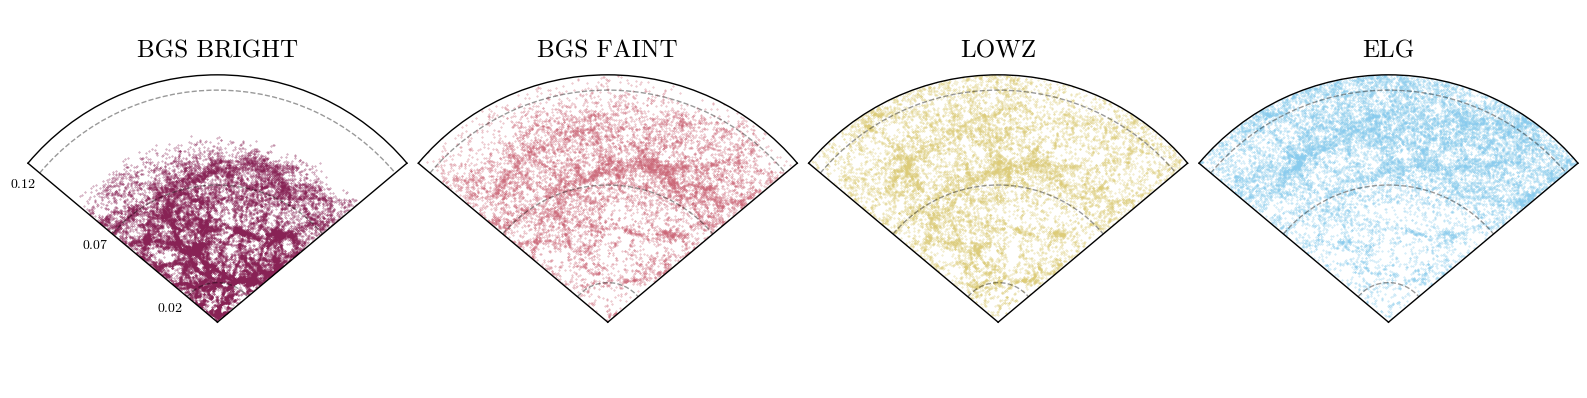

In [22]:

title_size = 19
ra_ticks_vals = np.array([130,150, 170, 190, 210, 230])
ra_min = 130
ra_max = 230
pad_val =-15

fig, ax = plt.subplots(1,4,figsize = (20,5),subplot_kw={'projection': 'polar'})
plt.subplots_adjust(wspace = 0.03, hspace = -1)

plot_ind = 0

ax = [ax[0], ax[1], ax[2], ax[3]  ]

for sample_name, color in sample_color_map.items():

    mask = samples_cat == sample_name
    
    ra_radians = np.deg2rad(tot_cat_slice[mask]["RA"])

    
    ax[plot_ind].grid(True, axis='y', linewidth=1, alpha=0.4,color="k",ls="--")
    ax[plot_ind].grid(False, axis='x')
            
    
    ax[plot_ind].scatter(ra_radians, tot_cat_slice["comov_dist"][mask], alpha=0.7,s=0.1,rasterized=True, color = color )
    
    # Add labels and a colorbar
    ax[plot_ind].set_theta_zero_location("S")  # Optional: sets 0° at the bottom (South)
    ax[plot_ind].set_theta_direction(-1)       # Optional: clockwise direction for RA
    # Set title and labels
    # ax.set_title('Galaxy Distribution by Redshift and RA')
    ax[plot_ind].set_thetamin(ra_min)   # Min angle in degrees (start of the slice)
    ax[plot_ind].set_thetamax(ra_max)
    ax[plot_ind].set_rlim(0,550)

    ax[plot_ind].set_rticks([88,305,516])

    ax[plot_ind].set_xticks([])
    # labels only on first panel
    if plot_ind == 0:
        ax[plot_ind].set_yticklabels([r"$0.02$", r"$0.07$", r"$0.12$"])
    else:
        pass
        ax[plot_ind].tick_params(axis='y', labelleft=False)


    if "BGS_" in sample_name:
        sample_name = sample_name.replace("BGS_", "BGS ")

    ax[plot_ind].text(np.deg2rad(180),        # angle in radians
        ax[plot_ind].get_rmax() * 1.1,   # just outside the outermost circle
        sample_name,
        color = "k",
        rotation=0,
        ha='center',
        va='center',
        fontsize=18)
    
    plot_ind += 1

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/zred_sample_slice.png",bbox_inches="tight")

plt.show()
    

In [23]:
Planck18.comoving_distance(0.02), Planck18.comoving_distance(0.07), Planck18.comoving_distance(0.12) 

(<Quantity 88.20208831 Mpc>,
 <Quantity 305.02911976 Mpc>,
 <Quantity 516.51109372 Mpc>)

In [24]:
from desi_lowz_funcs import get_stellar_mass_mia
from catalog_paper_plots import make_cmap

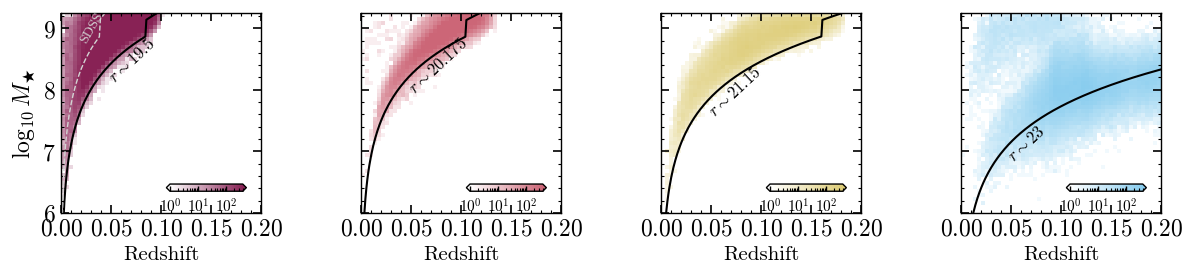

In [25]:

### 2d redshift vs. stellar mass distribution 

zgrid = np.arange(0.001,0.31,0.001)
gr_col = 0.1
mstar_195= get_stellar_mass_mia(gr_col,19.5,zred = zgrid*0, d_in_mpc = Planck18.luminosity_distance(zgrid).value, input_zred=False )
mstar_20= get_stellar_mass_mia(gr_col,20,zred = zgrid*0, d_in_mpc = Planck18.luminosity_distance(zgrid).value, input_zred=False)
mstar_21= get_stellar_mass_mia(gr_col,21,zred = zgrid*0, d_in_mpc = Planck18.luminosity_distance(zgrid).value, input_zred=False)
mstar_23= get_stellar_mass_mia(gr_col,23,zred = zgrid*0, d_in_mpc = Planck18.luminosity_distance(zgrid).value, input_zred=False)

mstar_grids = [ mstar_195, mstar_20, mstar_21, mstar_23 ]
labels = [r"$r \sim 19.5$", r"$r \sim 20.175$", r"$r \sim 21.15$", r"$r \sim 23$" ]
rmag_lims = [19.5, 20.175, 21.15, 23]


def fmt(x):
    return rf"r = %d"%x


fig,ax = make_subplots(ncol=4,nrow=1,return_fig=True,col_spacing = 1, row_spacing = 0.8)

samples = ["BGS_BRIGHT","BGS_FAINT","LOWZ","ELG"]

for i in range(1,4):
    ax[i].set_yticklabels([])

zmax = 0.2

for i in range(4):
    mask_i = (tot_cat["SAMPLE"] == samples[i] )
    
    cmap_i = make_cmap(sample_colors[samples[i]] )
    
    hist = ax[i].hist2d( tot_cat["Z"][mask_i], tot_cat["LOG_MSTAR_M24"][mask_i], range= ( (0,zmax), (6,9.25) ) , bins = 50, norm=LogNorm(vmin=1,vmax=400),cmap = cmap_i)
    ax[i].set_xlabel("Redshift",fontsize = 15)

    ##assuming an average color, of lets say g-r = 0.3, can I obtain a line for r ~ 19.5, 21, and 23
    ax[i].plot(zgrid, mstar_grids[i], color = "k",lw = 1.5)
    zind = 35
    ax[i].text(zgrid[zind]+0.0075,mstar_grids[i][zind] - 0.05,labels[i],color = "k",fontsize = 12,rotation =43)

    if i == 0:
        mstar_17= get_stellar_mass_mia(gr_col,17.7,zgrid)
        ax[i].text(0.017,8.78,"SDSS",color = "lightgrey",fontsize = 10,rotation =60)
        ax[i].plot(zgrid, mstar_17, color = "lightgrey",lw = 1,ls = "--")
        

    # ax[i].set_title(f"{text_titles[i]}", fontsize = 18)

    ax[i].set_xticks([0,0.05,0.1,0.15,0.2])
    # ax[i].set_xticklabels(["0.0", "","0.1","","0.2"])

    ax[i].tick_params(
            axis='both',
            which='major',
            labelsize=17,   # <-- change this
            length=6,
            width=1.2
        )
        
    ax[0].set_ylabel(r"$\log_{10}M_{\bigstar}$",fontsize = 17)

    fig.canvas.draw()

    # Get subplot position in figure coordinates
    p = ax[i].get_position().get_points().flatten()

    # Set colorbar size and position below the subplot
    cbar_height = 0.02
    cbar_padding = 0.06

    cax = fig.add_axes([
        p[0]+0.525*(p[2]-p[0]),                  # x0
        p[1] + cbar_padding,   # y0: a bit below the axis
        0.4*(p[2] - p[0]),           # width
        cbar_height            # height
    ])

    cbarticks = [1,1e1, 1e2, 500]
    cbar = plt.colorbar(hist[3], cax=cax, orientation='horizontal',
                        ticklocation='bottom', extend='both', ticks=cbarticks)
    cbar.ax.tick_params(labelsize=11)

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/zred_mstar_2d.png",bbox_inches="tight")
plt.show()

[0.10476510067114096, 0.97, 0.22, 0.5]
[0.3262416107382551, 0.97, 0.22, 0.5]
[0.5477181208053691, 0.97, 0.22, 0.5]
[0.7691946308724832, 0.97, 0.22, 0.5]


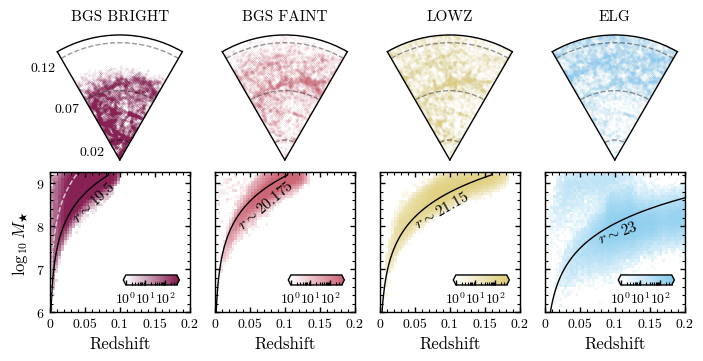

In [28]:
# ─────────────────────────────────────────────
# Step 1: Create the bottom row with make_subplots
# ─────────────────────────────────────────────
zgrid = np.arange(0.001,0.31,0.001)
gr_col = 0.35
mstar_195= get_stellar_mass_mia(gr_col,19.5,zred = zgrid*0, d_in_mpc = Planck18.luminosity_distance(zgrid).value, input_zred=False )
mstar_20= get_stellar_mass_mia(gr_col,20,zred = zgrid*0, d_in_mpc = Planck18.luminosity_distance(zgrid).value, input_zred=False)
mstar_21= get_stellar_mass_mia(gr_col,21,zred = zgrid*0, d_in_mpc = Planck18.luminosity_distance(zgrid).value, input_zred=False)
mstar_23= get_stellar_mass_mia(gr_col,23,zred = zgrid*0, d_in_mpc = Planck18.luminosity_distance(zgrid).value, input_zred=False)

mstar_grids = [ mstar_195, mstar_20, mstar_21, mstar_23 ]
labels = [r"$r \sim 19.5$", r"$r \sim 20.175$", r"$r \sim 21.15$", r"$r \sim 23$" ]
rmag_lims = [19.5, 20.175, 21.15, 23]


fig,ax_bot = make_subplots(nrow=1,ncol=4,return_fig=True,plot_size=1.4,
                       row_spacing= [MARGIN_LABEL, MARGIN_PAD] ,
                       col_spacing= [MARGIN_LABEL, MARGIN_SHARED+0.15, MARGIN_SHARED+0.15, MARGIN_SHARED+0.15, MARGIN_PAD]
                      )


# ─────────────────────────────────────────────
# Step 2: Draw bottom row content (your 2D hists)
# ─────────────────────────────────────────────
samples = ["BGS_BRIGHT", "BGS_FAINT", "LOWZ", "ELG"]
zmax = 0.2

for i in range(4):
    mask_i = tot_cat["SAMPLE"] == samples[i]
    cmap_i = make_cmap(sample_colors[samples[i]])
    hist = ax_bot[i].hist2d(
        tot_cat["Z"][mask_i], tot_cat["LOG_MSTAR_M24"][mask_i],
        range=((0, zmax), (6, 9.25)), bins=50,
        norm=LogNorm(vmin=1, vmax=400), cmap=cmap_i,
    )
    ax_bot[i].plot(zgrid, mstar_grids[i], color="k", lw=1)
    
    zind = 35
    rotation = 43
    yoff = 0.05
    if i == 0:
        zind = 20
    elif i == 1:
        zind = 20
        rotation = 40
    elif i == 2:
        zind = 37
        rotation = 30
        yoff= -0.025
    else:
        zind = 65
        rotation = 20
        yoff=-0.1
        
    ax_bot[i].text(zgrid[zind] + 0.0075, mstar_grids[i][zind] + yoff,
                   labels[i], color="k", rotation=rotation)

    # ax_bot[i].text(0.025, 8,
    #                labels[i], color="k", rotation=43)
    
    ax_bot[i].set_xlabel("Redshift")
    ax_bot[i].set_xticks([0, 0.05, 0.1, 0.15, 0.2])
    ax_bot[i].set_xticklabels(["0", "0.05", "0.1", "0.15", "0.2"])
    
    if i > 0:
        ax_bot[i].set_yticklabels([])

    # colorbar inside each panel
    fig.canvas.draw()
    p = ax_bot[i].get_position().get_points().flatten()
    cbar_height = 0.04
    cax = fig.add_axes([
        p[0] + 0.525 * (p[2] - p[0]),
        p[1] + 0.11,
        0.4 * (p[2] - p[0]),
        cbar_height,
    ])
    cbar = plt.colorbar(hist[3], cax=cax, orientation="horizontal",
                        extend="both", ticks=[1, 10, 100, 500])
    # cbar.ax.tick_params()

    if i == 0:
        mstar_17= get_stellar_mass_mia(gr_col,17.7,zred = zgrid*0, d_in_mpc = Planck18.luminosity_distance(zgrid).value, input_zred=False)
        # ax_bot[i].text(0.017,8.78,"SDSS",color = "lightgrey",fontsize = 10,rotation =60)
        ax_bot[i].plot(zgrid, mstar_17, color = "lightgrey",lw = 1,ls = "--")


ax_bot[0].set_ylabel(r"$\log_{10}M_{\bigstar}$")

# ─────────────────────────────────────────────
# Step 3: Place polar panels above, centered
# ─────────────────────────────────────────────
fig.canvas.draw()

bbox_left  = ax_bot[0].get_position()
bbox_right = ax_bot[-1].get_position()

# ─────────────────────────────────────────────
# For each polar panel, center its origin over
# the center of the corresponding bottom panel
# ─────────────────────────────────────────────
polar_height = 0.5   # make these bigger — tune as needed
polar_width  = 0.22  # width of the polar axes rect

ra_min, ra_max = 130+20, 230-20
mid_angle = np.deg2rad((ra_min + ra_max) / 2)  # 180° → points straight up

sample_color_map_list = list(sample_color_map.items())

ax_polar = []
for j in range(4):
    bbox_j = ax_bot[j].get_position()

    # center of the bottom panel in figure coords
    cx = bbox_j.x0 + bbox_j.width / 2
    cy = bbox_j.y1 + 0.05  # just above bottom panel top edge

    # The polar origin sits at the bottom-center of the polar axes rect
    # when theta_zero is "S" and the wedge is symmetric about 180°.
    # So place the rect so its bottom-center aligns with (cx, cy).
    rect = [
        cx - polar_width / 2,   # left edge
        cy,                      # bottom edge = polar origin
        polar_width,
        polar_height,
    ]

    ax_p = fig.add_axes(rect, projection="polar")
    sample_name, color = sample_color_map_list[j]
    mask = samples_cat == sample_name

    ra_radians = np.deg2rad(tot_cat_slice[mask]["RA"])
    ax_p.scatter(ra_radians, tot_cat_slice["comov_dist"][mask],
                 alpha=0.65, s=0.03, rasterized=True, color=color,marker=".")

    ax_p.set_theta_zero_location("S")
    ax_p.set_theta_direction(-1)
    ax_p.set_thetamin(ra_min)
    ax_p.set_thetamax(ra_max)
    ax_p.set_rlim(0, 550)
    ax_p.set_rticks([88, 305, 516])
    ax_p.set_xticks([])
    ax_p.grid(True, axis="y", linewidth=1, alpha=0.4, color="k", ls="--")
    ax_p.grid(False, axis="x")

    if j == 0:
        ax_p.set_yticklabels([r"$0.02$", r"$0.07$", r"$0.12$"])
    else:
        ax_p.tick_params(axis="y", labelleft=False)

    display_name = sample_name.replace("BGS_", "BGS ")
    ax_p.text(np.deg2rad(180), ax_p.get_rmax() * 1.15, display_name,
              color="k", rotation=0, ha="center", va="center")

    ax_polar.append(ax_p)

    print(rect)
    
plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/zred_mstar_2d_final.pdf")

plt.show()

## Make the catalog image grid plot!

In [48]:
from desi_lowz_funcs import save_jpg
import matplotlib.image as mpimg
import requests

In [49]:
len(tot_cat)

436191

In [53]:
# Example bins
rmag_bins = np.arange(17,21,0.25)
rmag_bins =  np.concatenate([[0], rmag_bins, [23] ] )
print(len(rmag_bins))
print(rmag_bins)

logm_bins = np.arange(6,9.5,0.5) 

mstar_vals = tot_cat["LOG_MSTAR_M24"].data
rmag_vals = tot_cat["MAG_R"].data

image_size = 115
save_path = "/pscratch/sd/v/virajvm/trash/desi_imgs"

session = requests.Session()

def swap(new_tgid):
    ra_i = tot_cat[tot_cat["TARGETID"] == new_tgid]["RA"][0]
    dec_i = tot_cat[tot_cat["TARGETID"] == new_tgid]["DEC"][0]
    return ra_i, dec_i, new_tgid
    
# Dummy images
images = {}
counts = {}
for i in range(len(rmag_bins)-1):
    for j in range(len(logm_bins)-1):
        logm_mask = (mstar_vals > logm_bins[j]) & (mstar_vals < logm_bins[j+1])
        rmag_mask = (rmag_vals > rmag_bins[i]) & (rmag_vals < rmag_bins[i+1])

        cat_i = tot_cat[rmag_mask & logm_mask]

        if len(cat_i) == 0:
            img = None #np.ones((image_size,image_size))
        else:    
            ra_i = cat_i["RA"].data[0]
            dec_i = cat_i["DEC"].data[0]
            tgid_i = cat_i["TARGETID"].data[0]

            if tgid_i == 39627600477290925:
                ra_i, dec_i, tgid_i = swap(39628516483926392)
            if tgid_i == 39627403265312105:
                ra_i, dec_i, tgid_i = swap(39627715183120706)    
            if tgid_i == 39627824155330825:
                ra_i, dec_i, tgid_i = swap(39628268134994442)    
            if tgid_i == 39627672900340781:
                ra_i, dec_i, tgid_i = swap(39627769608406676)    
            
            img_path = save_path + f"/img_{tgid_i}.jpg"
            #check if img exists first
            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
            else:
                save_jpg(ra_i,dec_i,img_path,session, size=image_size)
                
                img = mpimg.imread(img_path)

        if len(cat_i) == 110:
            print(tgid_i)
        
        images[(i,j)] = img
        counts[(i,j)] = len(cat_i)

18
[ 0.   17.   17.25 17.5  17.75 18.   18.25 18.5  18.75 19.   19.25 19.5
 19.75 20.   20.25 20.5  20.75 23.  ]
39627380314080359


In [51]:
import numpy as np

def reshape_axes(flat_axes, nrow, ncol):
    """
    Convert flat list from make_subplots (bottom-left, row-major, bottom-up)
    into a 2D array indexed as [row_from_top, col], matching plt.subplots.
    """
    arr = np.empty((nrow, ncol), dtype=object)
    for i in range(nrow):       # i = row from bottom
        for j in range(ncol):   # j = column from left
            arr[nrow - 1 - i, j] = flat_axes[i * ncol + j]
    return arr

def plot_tight_image_grid(images, counts, rmag_bins, logm_bins,fs = 8):
    Nx = len(rmag_bins) - 1  
    Ny = len(logm_bins) - 1 

    # fig, axes = plt.subplots(Ny, Nx, figsize=(int(Nx*2), int(Ny*2)))
    fig,flat_axes = make_subplots(ncol = 17, nrow = 6, plot_size = 0.378,
                            col_spacing = [MARGIN_PAD] + 16*[0.0075] + [MARGIN_PAD],
                            row_spacing = [MARGIN_PAD] + 5*[0.0075] + [MARGIN_PAD],
                                 return_fig=True)

    axes = reshape_axes(flat_axes, nrow=6, ncol=17)

    for j in range(Ny):
        for i in range(Nx):
            ax = axes[Ny - 1 - j, i]  # invert y so low mass is bottom
            img = images.get((i, j))

            if img is not None:
                ax.imshow(
                    img,
                    aspect='equal',
                    rasterized=True
                )

            ax.set_xticks([])
            ax.set_yticks([])
            ctsi = counts[(i,j)]
            if ctsi == 0:
                color_i ="k"
            else:
                color_i ="white"
                
            ax.text(0.925,0.85,ctsi, color=color_i,transform=ax.transAxes,ha="right",va="center",fontsize = fs-1)

            for spine in ax.spines.values():
                spine.set_visible(False)
            
            # Add axis labels only at edges
            if j == 0: # and i != Nx-1:  # bottom row: show rmag
                if rmag_bins[i+1] == 23:
                    ax.set_xlabel(f"{int(rmag_bins[i+1])}", rotation=0, labelpad=5,color = "k",fontsize = fs)
                    ax.xaxis.set_label_coords(1, -0.05)
                    
                elif rmag_bins[i+1] == 17:
                    ax.set_xlabel(fr"$<${int(rmag_bins[i+1])}", rotation=0, labelpad=5,color = "k",fontsize = fs)
                    ax.xaxis.set_label_coords(1, -0.05)
                # elif rmag_bins[i+1] == 20.75:
                #     ax.set_xlabel(fr"{rmag_bins[i+1]:.2f}$<$", rotation=0, labelpad=5,color = "k",fontsize = fs)
                #     ax.xaxis.set_label_coords(1, -0.05)
                else:
                    ax.set_xlabel(f"{rmag_bins[i+1]:.2f}", rotation=0, labelpad=5,color = "k",fontsize = fs)
                    ax.xaxis.set_label_coords(1, -0.05)
            
            if i == 0:  # left column: show logM*
                ax.set_ylabel(f"{logm_bins[j]:.1f}", rotation=0, color="k",fontsize = fs)
                ax.yaxis.set_label_coords(-0.25, -0.075)

            if ctsi == 110:
                print()


    # ax = axes[0, 0]  # invert y so low mass is bottom
    # ax.set_ylabel(f"{logm_bins[-1]:.1f}", rotation=0, color="k",fontsize = fs)
    # ax.yaxis.set_label_coords(-0.2, 1)

    # Add a big text label for the quantities being binned
    fig.text(0.5, -0.01, r"$r_{\rm mag}$", ha='center', va='center')
    fig.text(-0.005, 0.5, r"$\log_{10} M_{\bigstar}$", ha='center', va='center', rotation='vertical')

    return fig, axes


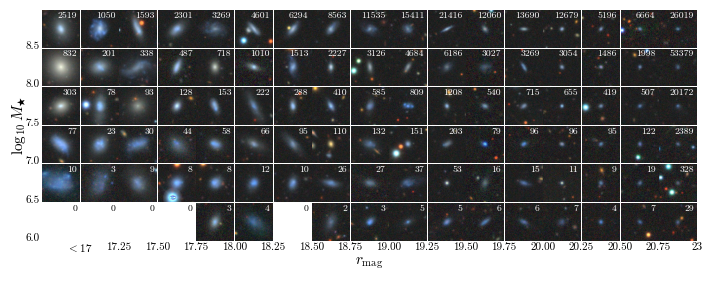

In [52]:

fig,ax = plot_tight_image_grid(images, counts, rmag_bins, logm_bins)

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/dwarf_imgs_grid.pdf")

plt.show()


In [54]:
tot_cat[tot_cat["TARGETID"]==39627380314080359]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,IS_BGS_BRIGHT,IS_BGS_FAINT,IS_LOWZ,IS_ELG,IS_OTHER,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE,PROPERTY_SOURCE_TARGETID
int64,bytes7,bytes6,int32,float64,float64,int32,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,int32,int32,bytes13,bool,float64,float64[2],bool,bool,bool,bool,bool,bool,object,int64,bool,bytes10,int64
39627380314080359,main,bright,36553,0.004131493077273984,71.21397510577299,0,0.0033516514318572277,33.471909984959524,-16.928211597197027,33.471909984959524,-16.928211597197027,DESI J033.4719-16.9282,14.338920593261719,7.45078706741333,0.011649397205049386,19.779233932495117,18.674165725708008,17.992393493652344,19.779233932495117,18.674165725708008,17.992393493652344,0,0,TRACTOR_OG,False,1.103179693222046,0.6365390419960022 .. 14.096561431884766,False,True,False,False,False,False,[39627380314080359],39627380314080359,True,CF3_NAM,39627380314080359


In [67]:
# fspec_tab = Table.read("/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits", hdu="FASTSPEC")
zcat = Table.read("/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits", hdu=2)


In [59]:
fspec_tab[fspec_tab["TARGETID"] == 39627380314080359]["SNR_B","HALPHA_FLUX","HALPHA_FLUX_IVAR", "HBETA_FLUX", "HBETA_FLUX_IVAR"]

SNR_B,HALPHA_FLUX,HALPHA_FLUX_IVAR,HBETA_FLUX,HBETA_FLUX_IVAR
float32,float32,float32,float32,float32
2.2192798,12.456245,0.24847005,10.359424,0.12664841


In [69]:
zcat[zcat["TARGETID"] == 39627380314080359]

TARGETID,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV1_SCND_TARGET,SV2_SCND_TARGET,SV3_SCND_TARGET,TSNR2_LRG,CHI2,OBJTYPE,OBSCONDITIONS,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMTILE,MEAN_PSF_TO_FIBER_SPECFLUX,MIN_MJD,MAX_MJD,MEAN_MJD,ZCAT_NSPEC,ZCAT_PRIMARY
int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,bytes3,int32,int16,float64,int16,float64,float64,float64,float64,int16,bool
39627380314080359,0,1152921504606846976,131074,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16.377260208129883,11456.5390625,TGT,516,2,3127.510009765625,1,0.7554397583007812,59538.29983205,59538.31546029,59538.30764617,1,True


In [70]:
zpix_iron = Table.read("/global/cfs/cdirs/desi/spectro/redux/iron/zcatalog/v1/zall-pix-iron.fits")

In [71]:
zpix_iron[zpix_iron["TARGETID"] == 39627380314080359]

TARGETID,SURVEY,PROGRAM,HEALPIX,SPGRPVAL,Z,ZERR,ZWARN,CHI2,COEFF,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,FA_TARGET,FA_TYPE,OBJTYPE,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKNAME,BRICKID,BRICK_OBJID,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV1_SCND_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV2_SCND_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV3_SCND_TARGET,PLATE_RA,PLATE_DEC,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,MEAN_FIBER_RA,STD_FIBER_RA,MEAN_FIBER_DEC,STD_FIBER_DEC,MIN_MJD,MAX_MJD,MEAN_MJD,TSNR2_GPBDARK_B,TSNR2_ELG_B,TSNR2_GPBBRIGHT_B,TSNR2_LYA_B,TSNR2_BGS_B,TSNR2_GPBBACKUP_B,TSNR2_QSO_B,TSNR2_LRG_B,TSNR2_GPBDARK_R,TSNR2_ELG_R,TSNR2_GPBBRIGHT_R,TSNR2_LYA_R,TSNR2_BGS_R,TSNR2_GPBBACKUP_R,TSNR2_QSO_R,TSNR2_LRG_R,TSNR2_GPBDARK_Z,TSNR2_ELG_Z,TSNR2_GPBBRIGHT_Z,TSNR2_LYA_Z,TSNR2_BGS_Z,TSNR2_GPBBACKUP_Z,TSNR2_QSO_Z,TSNR2_LRG_Z,TSNR2_GPBDARK,TSNR2_ELG,TSNR2_GPBBRIGHT,TSNR2_LYA,TSNR2_BGS,TSNR2_GPBBACKUP,TSNR2_QSO,TSNR2_LRG,MAIN_NSPEC,MAIN_PRIMARY,SV_NSPEC,SV_PRIMARY,ZCAT_NSPEC,ZCAT_PRIMARY,DESINAME
,,,,,,,,,,,,,,,,deg,deg,mas / yr,mas / yr,yr,,,,,,,,,,,mag,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy^-2,nanomaggy^-2,nanomaggy^-2,nanomaggy^-2,nanomaggy^-2,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,,,arcsec,,,,,mag,mag,mag,mas,,,,,,,,,,,,,,,,,,,,,deg,deg,,s,,,mm,mm,mm,mm,,deg,arcsec,deg,arcsec,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
int64,bytes7,bytes6,int32,int32,float64,float64,int64,float64,float64[10],int64,bytes6,bytes20,int64,float64,int32,float64,float64,float32,float32,float32,int64,uint8,bytes3,float64,int32,int16,bytes8,int32,int32,bytes4,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,int16,float32,int16,int16,float32,float32,float32,float32,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,bool,int16,bool,int16,bool,bytes22
39627380314080359,main,bright,36553,36553,0.004131493077273984,3.0421408249071016e-05,0,11456.538778154307,-4204.482014251582 .. 280.7499989007399,7925,GALAXY,--,10,71.21397510577299,0,33.471909984959524,-16.928211597197027,0.0,0.0,2015.5,1152921504606846976,1,TGT,0.7100472476501128,516,9010,0335m170,233948,1127,SER,0.03362893,11.093614,31.711056,61.200203,61.055164,40.24091,732.2769,381.17096,52.432686,2.066378,0.5851157,3.74779,10.713045,20.675455,3.74779,10.713045,20.675455,0,2.444001,1.1031797,0.19574238,0.1049259,0,--,0.0,0.0,0.0,0.0,S,2100,2,0,1152921504606846976,131074,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.471909984959524,-16.928211597197027,2,3127.51,1,1,-0.007,0.007,-0.001,0.001,0.75543976,33.47188124269434,0.0,-16.928207448269408,0.0,59538.29983205,59538.31546029,59538.30764617,21.058867,0.010076918,4.189796,5.6688533,61.354767,37.586937,0.25143218,0.12625977,1767.2472,4.2748604,349.819,0.008780974,399.4854,3072.9297,1.1791741,6.1046624,5.7354914e-06,22.588058,1.1364056e-06,0.0,996.7437,1.001972e-05,4.2975173,10.

In [88]:
1+1

2

In [99]:
import numpy as np
import h5py

H5_PATH = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5"
TARGETID = 39627087769770734 #39627380314080359

with h5py.File(H5_PATH, "r") as f:
    targetids = f["TARGETID"][:]
    idx = np.where(targetids == TARGETID)[0]
    if len(idx) == 0:
        raise ValueError(f"TARGETID {TARGETID} not found")
    idx = idx[0]

    wave = f["WAVE"][:]
    z_obj = f["Z"][idx]
    flux_obj = f["FLUX"][idx]
    ivar_obj = f["FLUX_IVAR"][idx]


In [100]:
z_obj

np.float32(0.07298073)

In [101]:
import numpy as np
from scipy.ndimage import uniform_filter1d, median_filter


def smooth_spectrum(wave, flux, ivar=None, mask=None, method="median", boxcar_A=80.0):
    """
    Smooth a 1D spectrum on a (possibly masked) pixel grid.

    Parameters
    ----------
    wave : array, shape (n,)
        Wavelength in Angstrom, increasing.
    flux : array, shape (n,)
        Flux in coadd units (typically 1e-17 erg/s/cm2/A).
    ivar : array, optional
        Inverse variance. Pixels with ivar <= 0 are ignored.
    mask : array, optional
        Bad-pixel mask. Nonzero = bad (DESI SPECMASK convention).
    method : {"median", "boxcar", "ivar_boxcar"}
    boxcar_A : float
        Smoothing scale in Angstrom.

    Returns
    -------
    flux_smooth : array
        Smoothed flux, same shape as input. Bad/input NaN pixels -> NaN.
    good : bool array
        Pixels used as valid input.
    """
    wave = np.asarray(wave, dtype=float)
    flux = np.asarray(flux, dtype=float)

    good = np.isfinite(flux)
    if ivar is not None:
        good &= np.asarray(ivar) > 0
    if mask is not None:
        good &= np.asarray(mask) == 0

    flux_out = np.full_like(flux, np.nan, dtype=float)
    if good.sum() < 5:
        return flux_out, good

    # Convert smoothing width in Angstrom to pixels (median spacing)
    dw = np.median(np.diff(wave[good]))
    if not np.isfinite(dw) or dw <= 0:
        return flux_out, good
    halfwin = max(1, int(round(0.5 * boxcar_A / dw)))

    if method == "median":
        # Fill bad pixels with NaN, median_filter ignores NaN in recent scipy
        tmp = flux.astype(float).copy()
        tmp[~good] = np.nan
        flux_smooth = median_filter(tmp, size=2 * halfwin + 1, mode="nearest")
        flux_out[good] = flux_smooth[good]

    elif method in ("boxcar", "ivar_boxcar"):
        tmp = flux.astype(float).copy()
        tmp[~good] = 0.0
        num = uniform_filter1d(tmp, size=2 * halfwin + 1, mode="nearest")
        den = uniform_filter1d(good.astype(float), size=2 * halfwin + 1, mode="nearest")

        if method == "ivar_boxcar" and ivar is not None:
            w = np.zeros_like(flux)
            w[good] = np.asarray(ivar)[good]
            num = uniform_filter1d(flux * w, size=2 * halfwin + 1, mode="nearest")
            den = uniform_filter1d(w, size=2 * halfwin + 1, mode="nearest")

        with np.errstate(invalid="ignore", divide="ignore"):
            flux_smooth = num / den
        flux_out[good] = flux_smooth[good]

    else:
        raise ValueError(f"Unknown method={method}")

    return flux_out, good



In [102]:
smooth_spec_2, _ = smooth_spectrum([wave], [flux_obj], ivar=None, mask=None, method="median", boxcar_A=200.0)

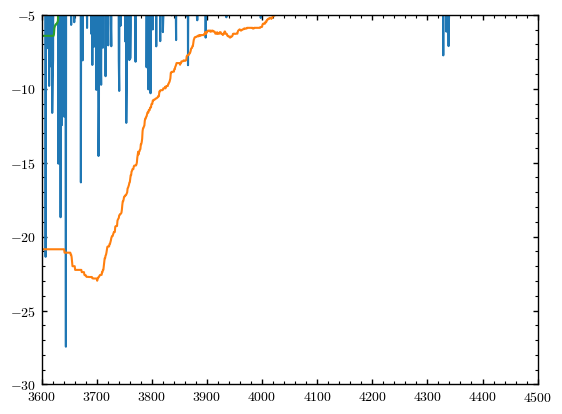

In [106]:
plt.plot(wave, flux_obj)
plt.plot(wave, smooth_spec[0])
plt.plot(wave, smooth_spec_2[0])
plt.xlim([3600,4500])
plt.ylim([-30,-5])
plt.show()



In [ ]:
## if all the points bluewards of the 

In [34]:
from desi_lowz_funcs import make_tall_subplots
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator


In [35]:
def make_spectra_panel_sample(tgids_interest, file_name, tot_cat, wave_min=3500, wave_max=9200,
                              save_folder="/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/example_spec/", lims=None):
    
    # fig, ax = plt.subplots(2, 2, figsize=(20, int(3*2)), sharex=True)
    fig, ax = make_tall_subplots(ncol=2, nrow = 2,
                                 panel_height = 1,
                                 panel_width = 3.15,
                                 row_spacing = [MARGIN_PAD, MARGIN_SHARED, MARGIN_PAD],
                                 col_spacing = [MARGIN_PAD, 0.25, MARGIN_PAD],
                                return_fig=True)
    
    fig.suptitle(r"$10^7 < M_{\bigstar} / M_{\odot} < 10^{7.5}$ galaxies in DESI between $19\lesssim r \lesssim 22$",y=1.02,ha="center",fontsize = 10)
    
    ax = [ax[0,0], ax[1,0], ax[0,1], ax[1,1]]
    sample_colors = ["#882255", "#CC6677", "#DDCC77", "#88CCEE"]
    print(f"Total number of TGIDS = {len(tgids_interest)}")
    image_size = 48
    session = requests.Session()
    
    for i in range(len(tgids_interest)):
        tgid_i = tgids_interest[i]
        npz_path = save_folder + f"spec_{tgid_i}.npz"
        img_path = save_folder + f"/img_{tgid_i}.jpg"
        
        # Check if cached npz exists - if so, load directly
        if os.path.exists(npz_path):
            print(f"Loading cached data for {tgid_i}")
            data = np.load(npz_path, allow_pickle=True)
            wave = data['wave']
            flux = data['flux']
            ivar = data['ivar']
            img = data['image']
            zred = float(data['zred'])
            mag_r = float(data['mag_r'])
            # dchi2 and logm available too if you need them later
        else:
            print(f"Downloading new data for {tgid_i}")
            temp = tot_cat[tot_cat["TARGETID"] == tgid_i]
            
            waves, fluxs, ivars = download_few_spectra(temp, ncores=1)
            ra_i = temp["RA"].data[0]
            dec_i = temp["DEC"].data[0]
            
            # Check if image exists first
            if not os.path.exists(img_path):
                print("Saving new jpg")
                save_jpg(ra_i, dec_i, img_path, session, size=image_size)
            img = mpimg.imread(img_path)
            
            zred = temp["Z"][0]
            mag_r = temp["MAG_R"][0]
            wave = waves['brz']
            flux = fluxs['brz'][0]
            ivar = ivars['brz'][0]
            
            # Save for future use
            np.savez(
                npz_path,
                wave=wave,
                flux=flux,
                ivar=ivar,
                image=img,
                zred=zred,
                mag_r=mag_r,
                dchi2=temp["DELTACHI2"][0],
                tgid=tgid_i,
                logm=temp["LOGM_SAGA"][0])
        
        # Main spectrum plotting (works for both cached and fresh data)
        ax[i].plot(wave/(1+zred), flux, color='grey', alpha=0.15, lw=1)
        ax[i].plot(wave[5:-5]/(1+zred), convolve(flux, Gaussian1DKernel(5))[5:-5], color=sample_colors[i], lw=1.5)
        
        ax[i].set_xlim([wave_min, wave_max])
        ax[i].tick_params(axis='both')
        ax[i].set_ylim([lims[i][0], lims[i][1]])
        if i == 0:
            ax[i].set_yticks([0, 6, 13])
        elif i == 1:
            ax[i].set_yticks([0, 2, 4])
        elif i == 2:
            ax[i].set_yticks([0, 5, 10])
        else:
            ax[i].set_yticks([0, 11, 23])
        
        ax[-1].set_xlabel(r'Rest-Frame Wavelength ($\AA$)',fontsize = 11)
        ax[1].set_xlabel(r'Rest-Frame Wavelength ($\AA$)',fontsize = 11)

        ax[0].set_xticklabels([])
        ax[2].set_xticklabels([])
        
        if i < 2:
            ax[i].set_ylabel(r'$F_{\lambda}$',fontsize = 11)
            ax[i].yaxis.set_label_coords(-0.04, 0.5)   # same x for both
        
        # Add inset axes in top-right
        inset_ax = inset_axes(ax[i],
                              width=0.675,
                              height=0.675,
                              loc='upper right',
                              bbox_to_anchor=(0.935, 0.78),
                              bbox_transform=ax[i].transAxes,
                              borderpad=0)
        
        inset_ax.imshow(img)
        inset_ax.set_title(f"{tgid_i}",fontsize = 8,y=0.95)
        inset_ax.axis('off')
        
        inset_ax.text(0.5, 0.95, "z=%.3f" % zred, color="white",fontsize = 9,
                      transform=inset_ax.transAxes, ha="center", verticalalignment='top')
        inset_ax.text(0.5, 0.2, "r=%.1f" % mag_r, color="white",fontsize = 9,
                      transform=inset_ax.transAxes, ha="center", verticalalignment='top')
        if i == 2 or i == 0:
            add_floating_emission_lines(ax[i], EMISSION_LINES,fontsize = 7)
    
    plt.tight_layout()
    plt.savefig(f"/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/{file_name}.pdf")
    plt.show()
    return

In [36]:
eg_tgids =  [39627427021851828, 39627491345697115, 2705980336898048, 39627555304643301] #  [  39627322709513192, 39627345413284126, 2705974209019904, 39627357518039557 ]

        

Total number of TGIDS = 4
Loading cached data for 39627427021851828
[OII] 3757.09
H$\gamma$ 4340.47
H$\beta$ 4861.33
[OIII] 5006.84
H$\alpha$ 6562.8
[SII] 6732.5
Loading cached data for 39627491345697115
Loading cached data for 2705980336898048
[OII] 3757.09
H$\gamma$ 4340.47
H$\beta$ 4861.33
[OIII] 5006.84
H$\alpha$ 6562.8
[SII] 6732.5
Loading cached data for 39627555304643301


/tmp/ipykernel_460224/2724940841.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


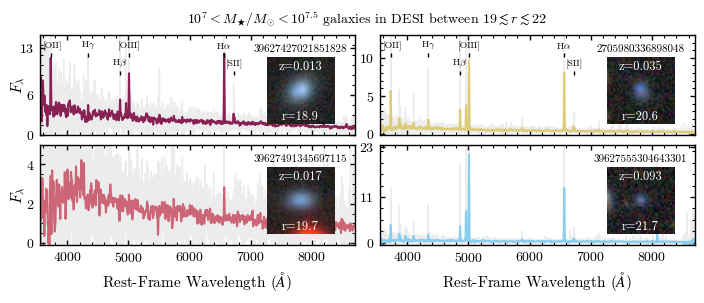

In [37]:

make_spectra_panel_sample(eg_tgids, "dwarf_egs", tot_cat, wave_min=3550, wave_max = 8700, lims =[ [0,15], [-0.1,5], [-0.1,13], [-0.5,23.5]  ] )


In [395]:

# make_spectra_panel_sample(eg_tgids, "dwarf_egs", tot_cat, wave_min=3550, wave_max = 9000, lims =[ [0,15], [-0.1,5], [-0.1,13], [-0.5,23.5]  ] )
